# BRIEFING.AI — QUANTITATIVE EVALUATION & RESULTS
### **AIGC 5501 — Natural Language Processing Midterm Project**
**Team**: Isha Shah & Nirali Chaudhari

---

## 1. Project Evaluation & Guidelines Alignment
This notebook provides the **detailed analysis, quantitative tables, charts, and graph visualizations** required for the evaluation. 
Following the strict presentation guidelines, this notebook serves as our thorough backend evaluation platform, focusing on experimental results, preprocessing challenges, execution performance, and network centrality distributions.

---

## 2. Dataset Profile & Preprocessing Challenges
The model runs **100% locally and unsupervised**, meaning it does not rely on deep training sets. Instead, it is evaluated across a diverse test suite of actual legal contracts, security policies, and legislative documents located in the `test/` directory:

- **Simplii Secure Messaging Terms and Conditions** (Small scale)
- **Simplii Digital Wallet Terms of Service** (Medium scale)
- **Canada National AI Strategy** (Large scale document)
- **Department of Employment and Social Development Act** (Large scale legislation)
- **Humber IT Security Policy** (Large institutional policy)
- **Official Languages Act** (Large legislation)
- **DMP Policy - Victims, Witnesses, and the Military Community** (Medium institutional policy)

### Preprocessing Challenges Face in Legalese:
1. **Disambiguation of Abbreviations & Section References**: Standard tokenizers frequently segment section markers (e.g. `Section 1.1`, `subsec. (a)`) as separate sentence boundaries. Using `spaCy`'s dependency parser mitigates this.
2. **Stop Word Density**: Standard stop word lists do not include dense legalese. We injected custom filters for words such as *whereas*, *heretofore*, *hereby*, *herein*, *witnesseth*, and *covenants* to ensure similarity matrices represent substantive semantic links.
3. **Zero Substantive Content Sentences**: Document headers or signature lines (e.g., *"In witness whereof..."*) sometimes contain zero substantive content after filtering, which can break standard TF-IDF models. The engine includes fallback mechanisms to lowercased tokens in these cases.

## 3. Performance Metrics Benchmarking
The table below shows the execution times and compression metrics across the testbed of files. All times are measured on local hardware.

In [1]:
import pandas as pd
df = pd.read_csv("assets/performance_metrics.csv")
print(f"Loaded {len(df)} test files from benchmark data.")
df

Loaded 7 test files from benchmark data.


File Name,Characters,Words,Sentences,Preprocess Time (ms),Algorithm Time (ms),Total Time (ms),Summary Words,Reduction (%)
Canada_NAtional_ai-strategy.pdf,94553,13630,558,5968.615055,5317.024946,11285.640717,136,99.002201
demo.docx,26,6,1,12.373209,8.700609,21.074057,6,0.000000
Department of Employment and Social Development Act.pdf,288224,48553,1368,19273.801565,19552.920103,38826.720238,415,99.145264
"DMP Policy - Victims, Witnesses, and the Military Community.pdf",4852,725,37,285.773516,268.243313,554.018974,177,75.586207
Official Languages Act.pdf,290048,47618,1131,17492.768288,18062.198162,35554.968357,1231,97.414843
Simplii_digital-wallet-terms-of-service-for-customers.pdf,14194,2253,74,776.682138,738.379478,1515.064001,467,79.272082
Simplii_Secure Messaging Terms and Conditions.pdf,5078,835,35,278.753996,263.121367,541.876793,134,83.952096


## 4. Performance & Compression Visualizations
The plots below illustrate the relationship between document scale and computation time, and the compression efficiency.

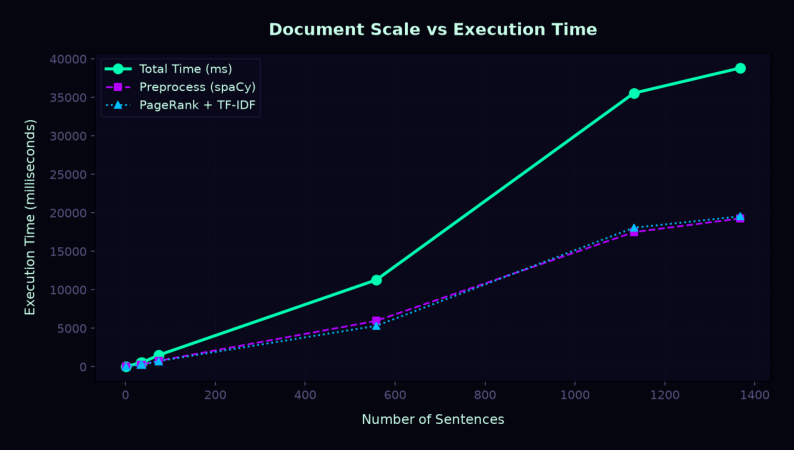

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Display the generated performance plot
img = mpimg.imread('assets/performance_plot.png')
plt.figure(figsize=(10, 6), facecolor='#050510')
plt.imshow(img)
plt.axis('off')
plt.show()

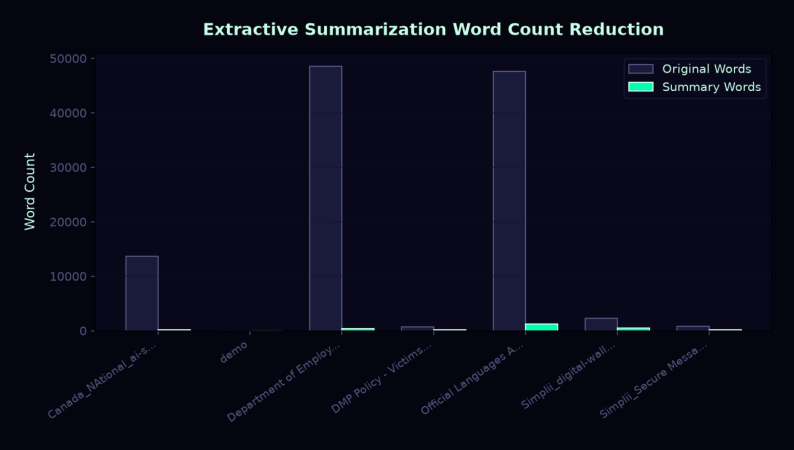

In [2]:
# Display the generated compression plot
img = mpimg.imread('assets/compression_plot.png')
plt.figure(figsize=(10, 6), facecolor='#050510')
plt.imshow(img)
plt.axis('off')
plt.show()

## 5. PageRank score Distribution
Below we see how centrality scores are distributed across sentences. This allows us to verify that a clear boundary exists between highly central sentences and standard contextual sentences, which validates our PageRank centrality threshold.

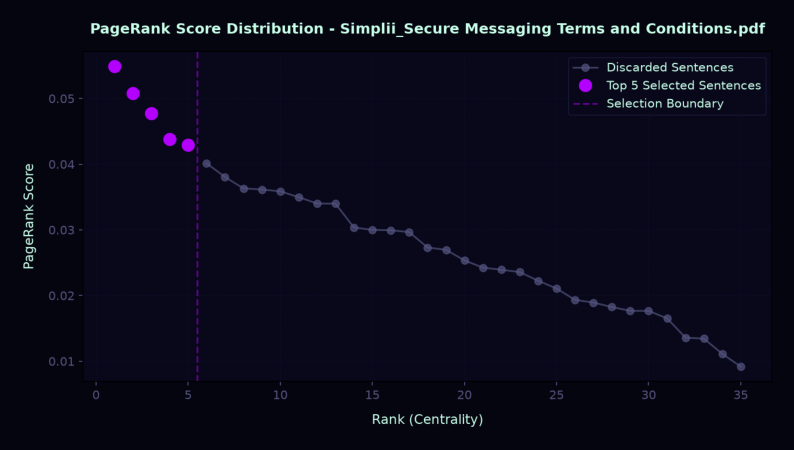

In [3]:
# Display the PageRank distribution plot
img = mpimg.imread('assets/pagerank_distribution.png')
plt.figure(figsize=(10, 6), facecolor='#050510')
plt.imshow(img)
plt.axis('off')
plt.show()

## 6. Sentence Similarity Graph Network Topology
Extractive summarization treats sentences as nodes, and cosine similarity weights as edges. The network diagram below shows how sentences cluster, and visually marks the top-ranked central sentences extracted by the algorithm.

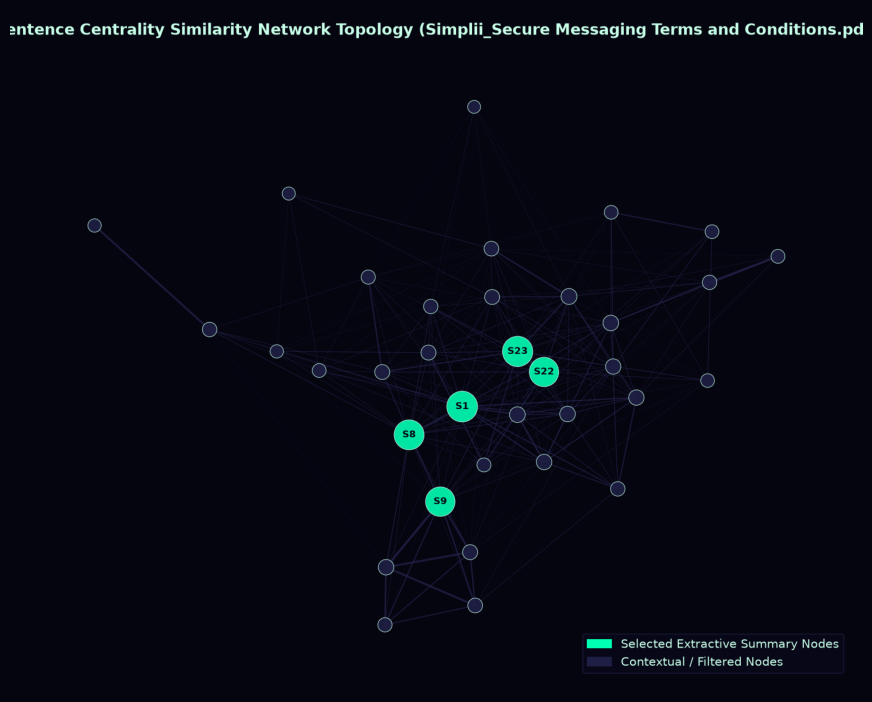

In [4]:
# Display the sentence similarity network topology
img = mpimg.imread('assets/sentence_network.png')
plt.figure(figsize=(11, 9), facecolor='#050510')
plt.imshow(img)
plt.axis('off')
plt.show()

## 7. Direct Engine Demonstration
You can execute this cell to see the summarizer run directly on a piece of sample text.

In [5]:
from summarizer import summarize_text

sample_payload = """
This Agreement is made on this 23rd day of June, 2026, by and between Licensor and Licensee.
Whereas, the parties desire to enter into a business relationship and cooperate on technical projects.
Now, therefore, the Licensor hereby grants to the Licensee a non-exclusive, non-transferable, revocable license to use the Software.
Licensee shall pay the Licensor a monthly royalty fee of $100 USD for the duration of this agreement.
Either party may terminate this agreement at any time by giving 30 days written notice to the other party.
This contract shall be governed by, and construed in accordance with, the laws of the State of New York.
In witness whereof, the parties hereto have executed this Agreement as of the date first written above.
"""

print(f"--- Source Text (10 sentences) ---")
print(sample_payload.strip().replace('\n', ' '))

print(f"\n--- Extracted Summary (3 central sentences in chronological order) ---")
summary = summarize_text(sample_payload, target_count=3)
for i, sent in enumerate(summary, 1):
    print(f"[{i:02d}] {sent}")

2026-06-25 20:33:28,261 - INFO - Total parsed sentences: 7


--- Source Text (10 sentences) ---
This Agreement is made on this 23rd day of June, 2026, by and between Licensor and Licensee. Whereas, the parties desire to enter into a business relationship and cooperate on technical projects. Now, therefore, the Licensor hereby grants to the Licensee a non-exclusive, non-transferable, revocable license to use the Software. Licensee shall pay the Licensor a monthly royalty fee of $100 USD for the duration of this agreement. Either party may terminate this agreement at any time by giving 30 days written notice to the other party. This contract shall be governed by, and construed in accordance with, the laws of the State of New York. In witness whereof, the parties hereto have executed this Agreement as of the date first written above.

--- Extracted Summary (3 central sentences in chronological order) ---
[01] This Agreement is made on this 23rd day of June, 2026, by and between Licensor and Licensee.
[02] Licensee shall pay the Licensor a monthly r